# Вывод

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Курс лекций [Semantic Technologies for Developers](https://yadi.sk/d/SepS4JBLhDYy4Q), лекция №04
* https://owl-rl.readthedocs.io/en/latest/
* https://trinidata.ru/tech_swrl.htm
* https://protege.stanford.edu/conference/2007/slides/08.01_OConnor.pdf
* https://www.youtube.com/watch?v=I81pLmK_lHg&ab_channel=ISEFIZKarlsruhe


## Вопросы для совместного обсуждения

1. Обсудите проблему вывода и различные подходы к решению этой проблемы.

In [1]:
turtle_data = """
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .
@prefix : <http://example.org/university#> .

# Define Classes
:Person rdf:type rdfs:Class .

:Student rdf:type rdfs:Class ;
        rdfs:subClassOf :Person .
        
:Professor rdf:type rdfs:Class ;
          rdfs:subClassOf :Person .
          
:Course rdf:type rdfs:Class .

# Define Properties
:teaches rdf:type rdf:Property ;
        rdfs:domain :Professor ;
        rdfs:range :Course .

:enrolledIn rdf:type rdf:Property ;
           rdfs:domain :Student ;
           rdfs:range :Course .

:name rdf:type rdf:Property ;
      rdfs:domain :Person ;
      rdfs:range xsd:string .

:age rdf:type rdf:Property ;
     rdfs:domain :Person ;
     rdfs:range xsd:integer .

# Instance Data
:john rdf:type :Student ;
      :name "John Smith" ;
      :age "20"^^xsd:integer ;
      :enrolledIn :CS101 .

:jane rdf:type :Professor ;
      :name "Jane Doe" ;
      :age "45"^^xsd:integer ;
      :teaches :CS101 .

:CS101 rdf:type :Course ;
       :name "Introduction to Computer Science" .
"""

## Задачи для самостоятельного решения

In [21]:
from rdflib import Graph, Namespace, RDF, RDFS, Literal, XSD, OWL
import owlrl

<p class="task" id="1"></p>


1\. Дан файл `data/animals.ttl`, содержащий онтологию, описывающую животный мир, а также информацию о нескольких экземплярах. 

Реализуйте следующие правила вывода и добавьте новые тройки в граф на основе сделанных выводов. Сериализуйте расширенный граф в формат turtle и сохраните на диск. Правила реализуйте по следующему принципу:

1 шаг: найти все ресурсы, удовлетворяющие некоему условию (при помощи методов графа или SPARQL);

2 шаг: добавить новые тройки на основе логического правила  (при помощи метода графа или SPARQL).

Правила для реализации:
* если X имеет шерсть, то X - это млекопитающее;
* если X ест мясо, то X - это хищник;
* если X принадлежит классу А, а класс А является подклассом Б, то X принадлежит и классу А;
* если X - млекопитающее, то X дышит легкими.


- [ ] Проверено на семинаре

In [3]:
turtle_data = """
@prefix : <http://fa.ru/animals#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Классы
:Animal a rdfs:Class .
:Mammal a rdfs:Class ;
    rdfs:subClassOf :Animal .
:Predator a rdfs:Class ;
    rdfs:subClassOf :Animal .

# Свойства
:hasHair a rdf:Property ;
    rdfs:domain :Animal ;
    rdfs:range xsd:boolean .

:eatsMeat a rdf:Property ;
    rdfs:domain :Animal ;
    rdfs:range xsd:boolean .
    
:breathesWithLungs a rdf:Property ;
    rdfs:domain :Animal ;
    rdfs:range xsd:boolean .

# Экземпляры
:Cat :hasHair true .
:Dog a :Animal ;
    :eatsMeat true .
:Fox a :Animal ;
    :eatsMeat true .
"""

In [4]:
g = Graph()
g.parse(data=turtle_data, format="turtle")

<Graph identifier=Na7c5b1fba7e24376a658d98b75e3fe7b (<class 'rdflib.graph.Graph'>)>

In [ ]:
# Определяем пространство имен (чтобы удобно обращаться)
NS = Namespace("http://fa.ru/animals#")
print(f"Количество троек до вывода: {len(g)}")

Количество троек до вывода: 19


In [6]:
# Правило 1: если X имеет шерсть (:hasHair true), то X - это млекопитающее (:Mammal)
candidates_rule1 = []
for s, p, o in g.triples((None, NS.hasHair, Literal(True))):
    candidates_rule1.append(s)

# Шаг 2: Добавить
for subject in candidates_rule1:
    g.add((subject, RDF.type, NS.Mammal))
    print(f"[Правило 1] {subject.split('#')[-1]} теперь Mammal")

[Правило 1] Cat теперь Mammal


In [7]:
# Правило 2: если X ест мясо (:eatsMeat true), то X - это хищник (:Predator)
candidates_rule2 = []
for s, p, o in g.triples((None, NS.eatsMeat, Literal(True))):
    candidates_rule2.append(s)

for subject in candidates_rule2:
    g.add((subject, RDF.type, NS.Predator))
    print(f"[Правило 2] {subject.split('#')[-1]} теперь Predator")

[Правило 2] Dog теперь Predator
[Правило 2] Fox теперь Predator


In [8]:
# Правило 3: если X принадлежит классу А, а класс А подкласс Б, то X принадлежит классу Б
triples_to_add = []
for subject in g.subjects(RDF.type, None): # Берем все ресурсы с типом
    for class_a in g.objects(subject, RDF.type): # Получаем их класс (А)
        for class_b in g.objects(class_a, RDFS.subClassOf): # Ищем родителя класса А (Б)
            if (subject, RDF.type, class_b) not in g: # Чтобы не дублировать, если уже есть
                triples_to_add.append((subject, RDF.type, class_b))

for s, p, o in triples_to_add:
    g.add((s, p, o))
    print(f"[Правило 3] {s.split('#')[-1]} наследует тип {o.split('#')[-1]}")

[Правило 3] Cat наследует тип Animal


In [9]:
# Правило 4: если X - млекопитающее, то X дышит легкими (:breathesWithLungs true)
candidates_rule4 = []
for s, p, o in g.triples((None, RDF.type, NS.Mammal)):
    candidates_rule4.append(s)

for subject in candidates_rule4:
    g.add((subject, NS.breathesWithLungs, Literal(True)))
    print(f"[Правило 4] {subject.split('#')[-1]} теперь дышит легкими")

[Правило 4] Cat теперь дышит легкими


In [10]:
print(f"Количество троек после вывода: {len(g)}")


output_file = "animals_inference.ttl"
g.serialize(destination=output_file, format="turtle")
print(f"Файл сохранен как {output_file}")


print("\n--- Итоговый граф (Turtle) ---")
print(g.serialize(format="turtle"))

Количество троек после вывода: 24
Файл сохранен как animals_inference.ttl

--- Итоговый граф (Turtle) ---
@prefix : <http://fa.ru/animals#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

:Animal a rdfs:Class .

:Mammal a rdfs:Class ;
    rdfs:subClassOf :Animal .

:Predator a rdfs:Class ;
    rdfs:subClassOf :Animal .

:Cat a :Animal,
        :Mammal ;
    :breathesWithLungs true ;
    :hasHair true .

:Dog a :Animal,
        :Predator ;
    :eatsMeat true .

:Fox a :Animal,
        :Predator ;
    :eatsMeat true .

:breathesWithLungs a rdf:Property ;
    rdfs:domain :Animal ;
    rdfs:range xsd:boolean .

:eatsMeat a rdf:Property ;
    rdfs:domain :Animal ;
    rdfs:range xsd:boolean .

:hasHair a rdf:Property ;
    rdfs:domain :Animal ;
    rdfs:range xsd:boolean .




<p class="task" id="2"></p>


2\. Дан файл `data/people.ttl`, содержащий онтологию, описывающую отношения между людьми, а также информацию о нескольких экземплярах. 

Реализуйте правила вывода на основе свойств отношений `owl:SymmetricProperty` и `owl:TransitiveProperty`. Сериализуйте расширенный граф в формат turtle и сохраните на диск. Подход к реализации правил аналогичен заданию 1.


- [ ] Проверено на семинаре

In [11]:
people_data = """
@prefix : <http://fa.ru/work#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Определение классов
:Person rdf:type owl:Class .

# Определение свойств
:knows rdf:type owl:ObjectProperty ;
    rdf:type owl:SymmetricProperty .

:isAncestorOf rdf:type owl:ObjectProperty ;
    rdf:type owl:TransitiveProperty .

# Индивиды
:Alice rdf:type :Person .
:Bob rdf:type :Person .
:Charlie rdf:type :Person .
:David rdf:type :Person .

# Отношения
:Alice :knows :Bob .
:Bob :isAncestorOf :Charlie .
:Charlie :isAncestorOf :David .
"""

In [12]:
g2 = Graph()
g2.parse(data=people_data, format="turtle")

<Graph identifier=N87183986a4b6418f8f1319a347b3f7d3 (<class 'rdflib.graph.Graph'>)>

In [13]:
NS = Namespace("http://fa.ru/work#")
print(f"Количество троек до вывода: {len(g2)}")

Количество троек до вывода: 12


In [15]:
# --- ПРАВИЛО 1: Симметричность (SymmetricProperty) ---
symmetric_props = []
for s, p, o in g2.triples((None, RDF.type, OWL.SymmetricProperty)):
    symmetric_props.append(s)

new_symmetric_triples = []
for prop in symmetric_props:
    for s, o in g2.subject_objects(prop):
        if (o, prop, s) not in g2:
            new_symmetric_triples.append((o, prop, s))

for s, p, o in new_symmetric_triples:
    g2.add((s, p, o))
    print(f"[Symmetry] Добавлено: {s.split('#')[-1]} {p.split('#')[-1]} {o.split('#')[-1]}")

[Symmetry] Добавлено: Bob knows Alice


In [16]:
# --- ПРАВИЛО 2: Транзитивность (TransitiveProperty) ---
transitive_props = []
for s, p, o in g2.triples((None, RDF.type, OWL.TransitiveProperty)):
    transitive_props.append(s)

iteration = 0
while True:
    iteration += 1
    new_transitive_triples = []
    
    for prop in transitive_props:
        for x, y in g2.subject_objects(prop):
            for z in g2.objects(y, prop):
                if (x, prop, z) not in g2 and x != z:
                    if (x, prop, z) not in new_transitive_triples:
                        new_transitive_triples.append((x, prop, z))
    
    if not new_transitive_triples:
        break
        
    for s, p, o in new_transitive_triples:
        g2.add((s, p, o))
        print(f"[Transitivity Iter {iteration}] Добавлено: {s.split('#')[-1]} {p.split('#')[-1]} {o.split('#')[-1]}")

[Transitivity Iter 1] Добавлено: Bob isAncestorOf David


In [17]:
print(f"Количество троек после вывода (g2): {len(g2)}")

output_file = "people_inference.ttl"
g2.serialize(destination=output_file, format="turtle")
print(f"Файл сохранен как {output_file}")

print("\n--- Проверка ключевых фактов в g2 ---")
if (NS.Bob, NS.knows, NS.Alice) in g2:
    print("OK: Боб теперь знает Алису.")
if (NS.Bob, NS.isAncestorOf, NS.David) in g2:
    print("OK: Боб теперь предок Дэвида.")

Количество троек после вывода (g2): 14
Файл сохранен как people_inference.ttl

--- Проверка ключевых фактов в g2 ---
OK: Боб теперь знает Алису.
OK: Боб теперь предок Дэвида.


<p class="task" id="3"></p>


3\. Дан файл `data/work.ttl`, содержащий онтологию, описывающую рабочие отношения между людьми, а также информацию о нескольких экземплярах. 

Реализуйте правила, которые проверяют согласованность данных представленной онтологии. Выведите на экран информацию по каждому из утверждений: согласуется ли оно с онтологией, либо нарушает какое-то правила (если да, то какое).


- [ ] Проверено на семинаре

In [18]:
work_data = """
@prefix : <http://fa.ru/relationships#> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Определение класса
:Person rdf:type owl:Class .

# Определение свойства
:isManagerOf rdf:type owl:ObjectProperty ;
    rdfs:domain :Person ;
    rdfs:range :Person ;
    rdf:type owl:AsymmetricProperty ;
    rdf:type owl:IrreflexiveProperty .

# Экземпляры
:Alice rdf:type :Person .
:Bob rdf:type :Person .
:Charlie rdf:type :Person .
:David rdf:type :Person .

# Утверждения (факты, которые нужно проверить)
:Alice :isManagerOf :Bob .
:Alice :isManagerOf :Adam .
:Bob :isManagerOf :Alice .
:Bob :isManagerOf :Charlie .
:Adam :isManagerOf :Adam .
"""

In [19]:
g3 = Graph()
g3.parse(data=work_data, format="turtle")
NS = Namespace("http://fa.ru/relationships#")

print(f"Всего утверждений в графе g3: {len(g3)}\n")


Всего утверждений в графе g3: 15



In [20]:
# 3. Проходимся по всем утверждениям isManagerOf
for s, p, o in g3.triples((None, NS.isManagerOf, None)):
    subj_name = s.split('#')[-1]
    obj_name = o.split('#')[-1]
    
    violations = []
    
    # --- ПРОВЕРКА 1: IrreflexiveProperty (Иррефлексивность) ---
    # Субъект и Объект не должны совпадать (сам себе начальник)
    if s == o:
        violations.append("Нарушение IrreflexiveProperty: Объект связан сам с собой (руководит сам собой).")
        
    # --- ПРОВЕРКА 2: AsymmetricProperty (Асимметричность) ---
    # Если есть связь A -> B, то не должно быть связи B -> A
    if (o, p, s) in g3:
        violations.append(f"Нарушение AsymmetricProperty: Найдена обратная связь ({obj_name} isManagerOf {subj_name}).")

    print(f"Факт: {subj_name} isManagerOf {obj_name}")
    if len(violations) == 0:
        print("  ✅ Статус: Корректно")
    else:
        print("  ❌ Статус: ОШИБКА")
        for v in violations:
            print(f"     -> {v}")
    print("-" * 40)

Факт: Alice isManagerOf Bob
  ❌ Статус: ОШИБКА
     -> Нарушение AsymmetricProperty: Найдена обратная связь (Bob isManagerOf Alice).
----------------------------------------
Факт: Alice isManagerOf Adam
  ✅ Статус: Корректно
----------------------------------------
Факт: Adam isManagerOf Adam
  ❌ Статус: ОШИБКА
     -> Нарушение IrreflexiveProperty: Объект связан сам с собой (руководит сам собой).
     -> Нарушение AsymmetricProperty: Найдена обратная связь (Adam isManagerOf Adam).
----------------------------------------
Факт: Bob isManagerOf Alice
  ❌ Статус: ОШИБКА
     -> Нарушение AsymmetricProperty: Найдена обратная связь (Alice isManagerOf Bob).
----------------------------------------
Факт: Bob isManagerOf Charlie
  ✅ Статус: Корректно
----------------------------------------


<p class="task" id="4"></p>


4\. Используя пакет `owlrl`, сделайте автоматический вывод на основе имеющейся онтологии. Выведите на экран тройки для каждого человека до процедуры вывода и после. Покажите, какие тройки были добавлены.


- [ ] Проверено на семинаре

In [22]:
g4 = Graph()
g4.parse(data=people_data, format="turtle")
NS = Namespace("http://fa.ru/work#")

In [23]:
# Список наших персонажей для отслеживания
people = [NS.Alice, NS.Bob, NS.Charlie, NS.David]

# Функция для красивого вывода связей человека
def print_person_relations(graph, person_uri, label):
    name = person_uri.split('#')[-1]
    print(f"--- {name} ({label}) ---")
    found = False
    for s, p, o in graph.triples((person_uri, None, None)):
        prop_name = p.split('#')[-1]
        obj_name = o.split('#')[-1]
        if prop_name != "type": 
            print(f"  {name} {prop_name} {obj_name}")
            found = True
    if not found:
        print("  (Нет связей)")
    print()

In [24]:
triples_before = set(g4) 
for p in people:
    print_person_relations(g4, p, "DO")

print(">>> Запуск owlrl ризонера... <<<")
owlrl.DeductiveClosure(owlrl.OWLRL_Semantics).expand(g4)

print("\n=== СОСТОЯНИЕ ПОСЛЕ ВЫВОДА ===")
triples_after = set(g4) 
new_triples = triples_after - triples_before 

# Выводим состояние для каждого человека и подсвечиваем новые факты
for p in people:
    name = p.split('#')[-1]
    print(f"--- {name} (POSLE) ---")
    found = False
    for s, pred, o in g4.triples((p, None, None)):
        prop_name = pred.split('#')[-1]
        obj_name = o.split('#')[-1]
        
        if prop_name == "type" or "owl" in str(pred): 
            continue
            
        is_new = (s, pred, o) in new_triples
        marker = "[NEW!]" if is_new else ""
        
        print(f"  {marker} {name} {prop_name} {obj_name}")
    print()

print(f"Всего добавлено новых троек: {len(new_triples)}")

--- Alice (DO) ---
  Alice knows Bob

--- Bob (DO) ---
  Bob isAncestorOf Charlie

--- Charlie (DO) ---
  Charlie isAncestorOf David

--- David (DO) ---
  (Нет связей)

>>> Запуск owlrl ризонера... <<<

=== СОСТОЯНИЕ ПОСЛЕ ВЫВОДА ===
--- Alice (POSLE) ---
   Alice knows Bob

--- Bob (POSLE) ---
   Bob isAncestorOf Charlie
  [NEW!] Bob isAncestorOf David
  [NEW!] Bob knows Alice

--- Charlie (POSLE) ---
   Charlie isAncestorOf David

--- David (POSLE) ---

Всего добавлено новых троек: 132


<p class="task" id="5"></p>


5\. Используя Protégé, опишите семейную онтологию.


Классы: 
- Person
- Male (подкласс Person)
- Female (подкласс Person)

Объектные свойства: 
- hasParent
- hasChild
- hasSibling
- isMarriedTo
- hasGrandparent
- hasUncleAunt
- hasFatherInLaw

Индивиды: 
1. John: Male
2. Mary: Female
3. Peter: Male
4. Emma: Female
5. Tom: Male
6. Lisa: Female

Факты: 
- John isMarriedTo Mary
- Peter hasParent John
- Peter hasParent Mary
- Emma hasParent John
- Emma hasParent Mary
- Tom hasParent Peter
- Lisa hasParent Peter


После завершения формирования онтологии и создания индивидов сделайте скриншоты иерархии классов, object properties и data properties и вставьте в ноутбук.

- [ ] Проверено на семинаре

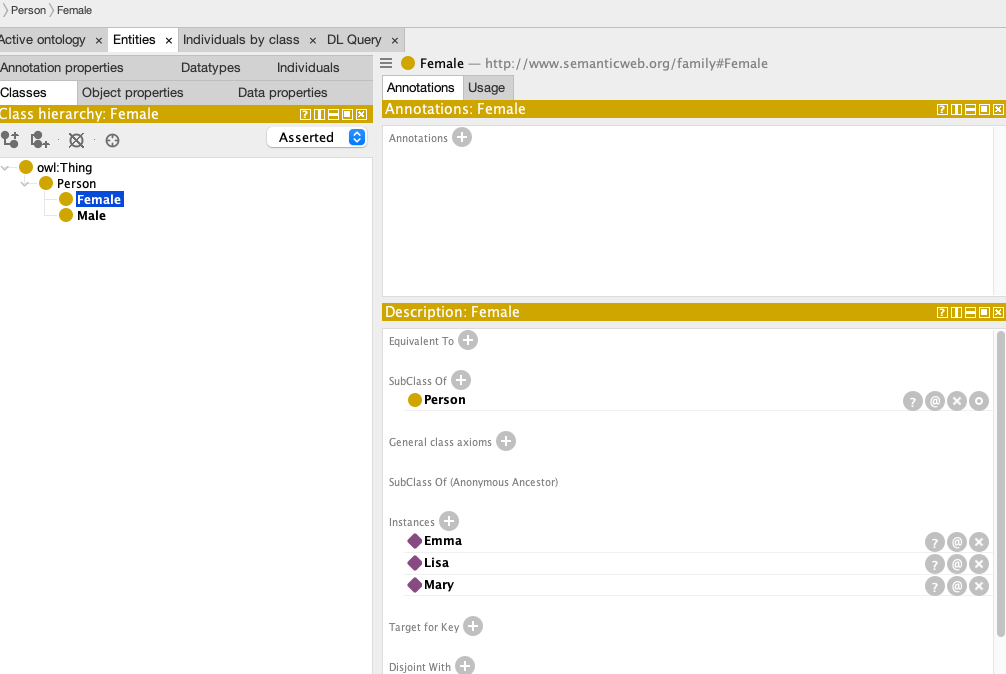

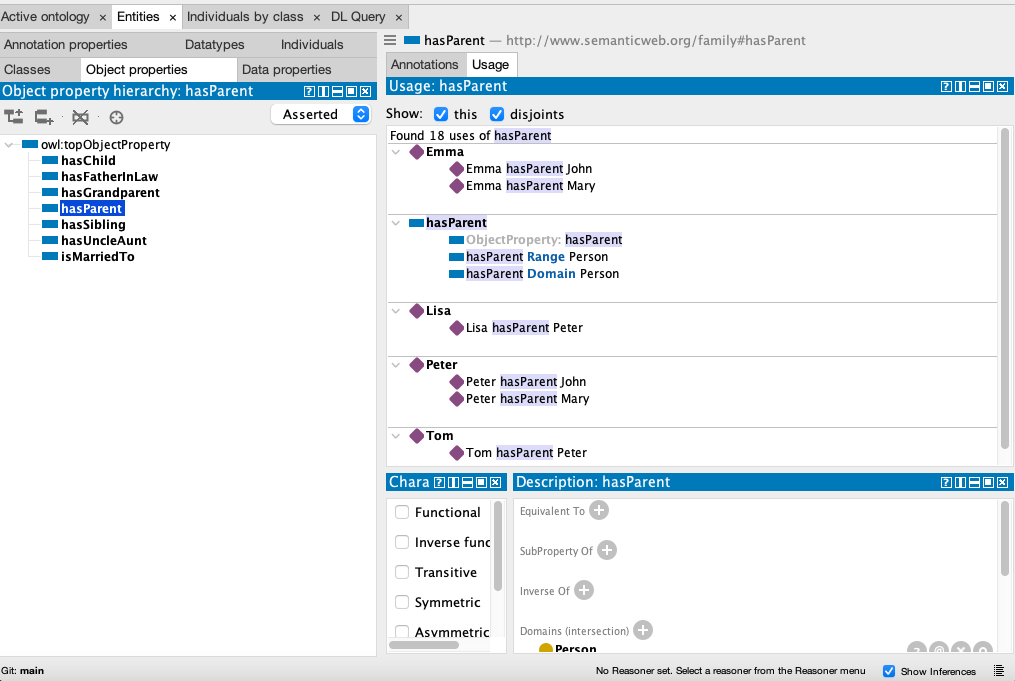

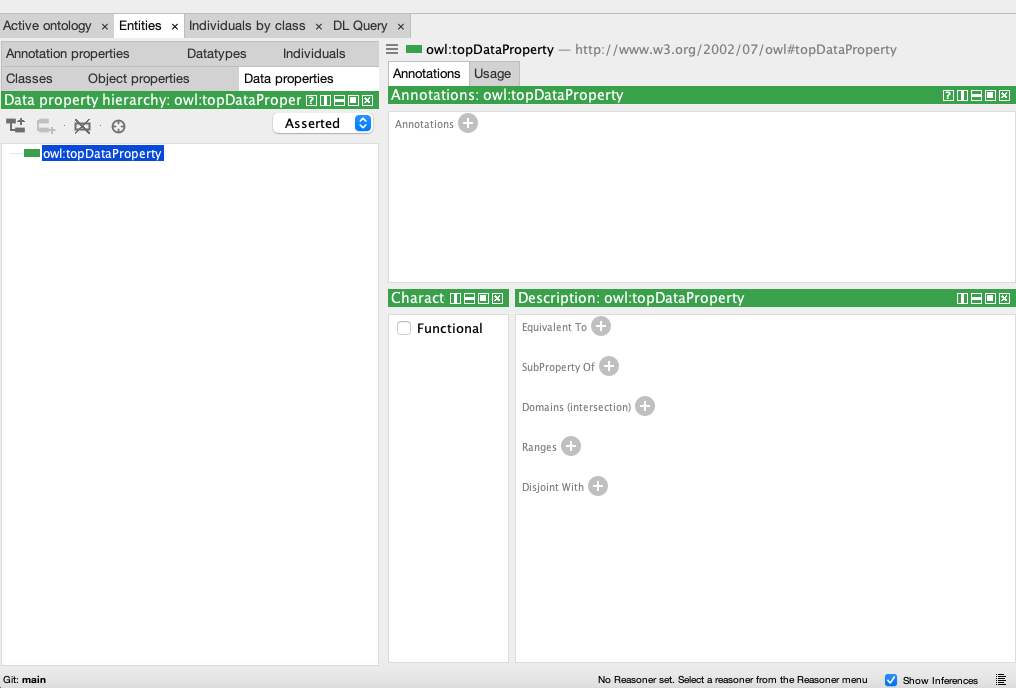

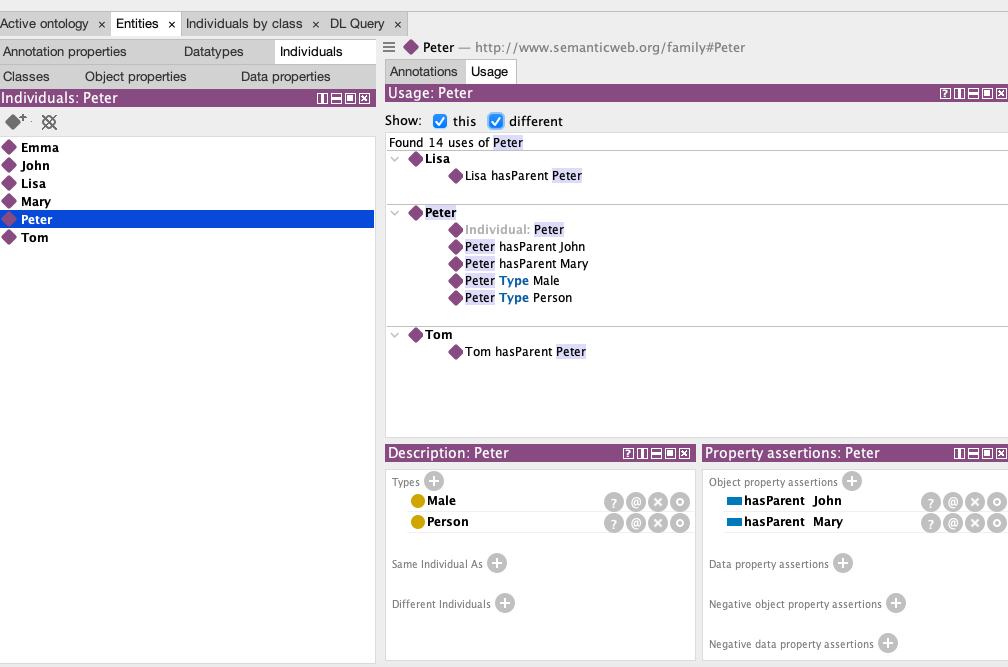

<p class="task" id="6"></p>


6\. Опишите следующие правила на языке SWRL. Используя reasoner HermiT получите новые выведенные факты. 

- Правило определения отношения дедушка/бабушка:
"Если у человека Y есть родитель X, а у человека Z есть родитель Y, то X является дедушкой или бабушкой Z."

- Правило определения отношения брат/сестра:
"Если у двух разных людей X и Y есть общий родитель Z, то X и Y являются братом/сестрой друг другу."

- Правило определения отношения дядя/тётя:
"Если у человека Y есть брат или сестра X, а у человека Z родитель Y, то X является дядей или тётей Z."

- Правило определения отношения тесть/свекор:
"Если мужчина X является родителем человека Y, который состоит в браке с человеком Z, то X является тестем или свекром для Z."

Сделайте скриншот вкладки с правилами и скриншоты с выведенными фактами и вставьте в виде текстовой ячейки.

- [ ] Проверено на семинаре

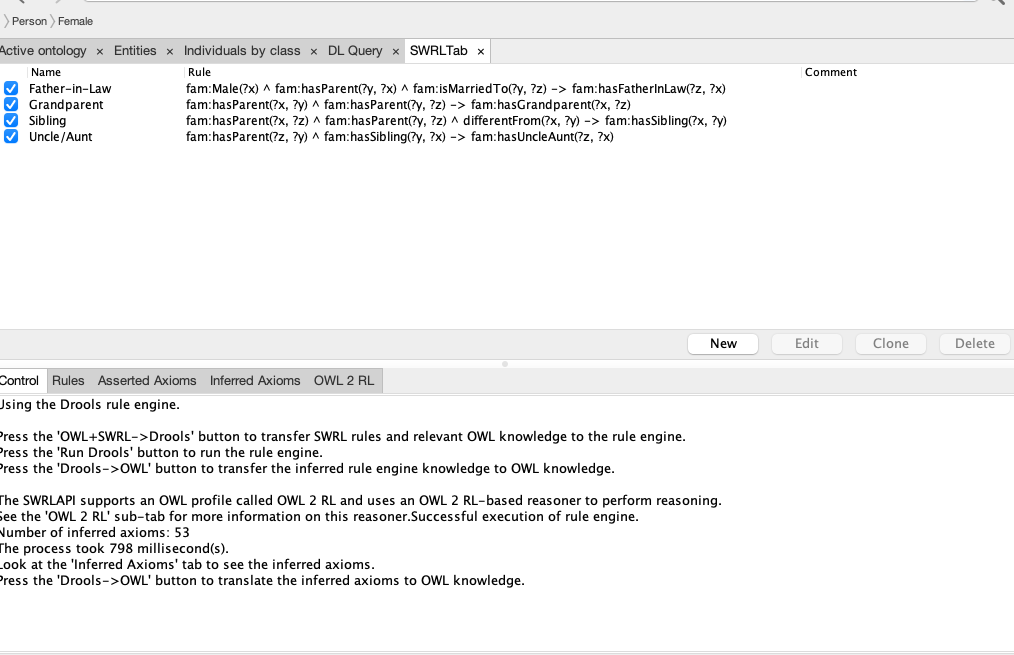

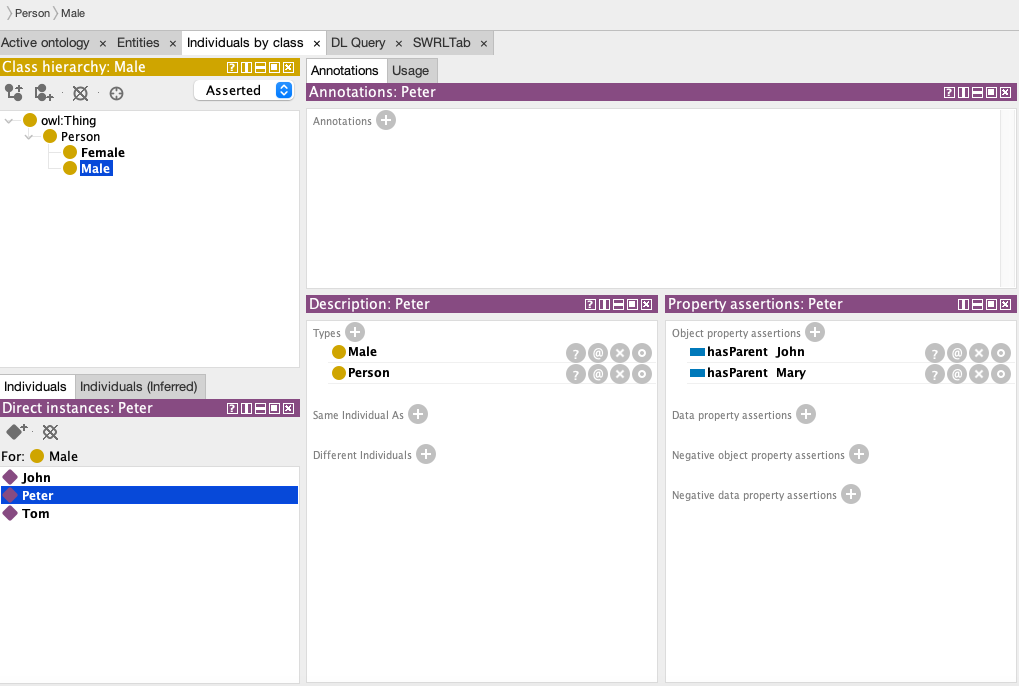